Training started
0 loss: 1021132.6875 mape: 132.3082275390625
200 loss: 77868.1640625 mape: 28.29705238342285
400 loss: 51750.6796875 mape: 26.22700309753418
600 loss: 17828.603515625 mape: 11.461915016174316
800 loss: 11355.79296875 mape: 8.351285934448242
1000 loss: 9277.078125 mape: 6.773338317871094
1200 loss: 8301.734375 mape: 5.933980464935303
Linear regression MAPE: 32.1292724609375
VAE MAPE: 20.034732818603516
Difference: 12.094539642333984


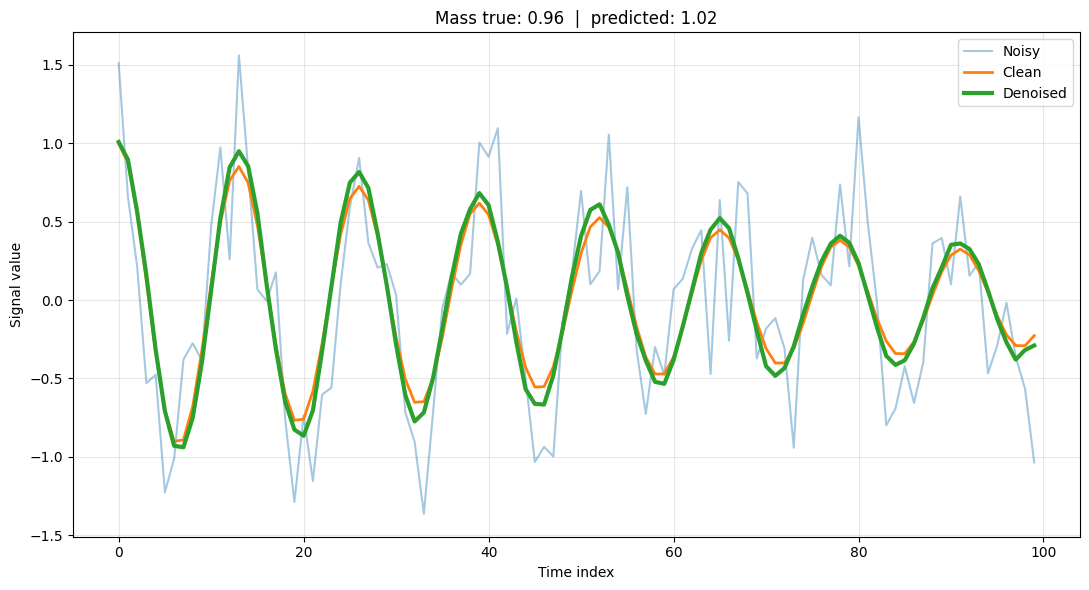

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression

def synthetic_noise(n_samples=1000, noise_level=0.3):
    t = torch.linspace(0, 5, 100)
    noisy_signals, clean_signals, parameters = [], [], []
    for _ in range(n_samples):
        mass = torch.rand(1) * 2.0 + 0.5
        spin = torch.rand(1) * 0.5 + 0.1
        clean = torch.exp(-t * spin) * torch.cos(mass * 10 * t)
        noise = torch.randn_like(clean) * noise_level
        noisy_signals.append(clean + noise)
        clean_signals.append(clean)
        parameters.append(torch.tensor([mass, spin]))
    return torch.stack(noisy_signals), torch.stack(clean_signals), torch.stack(parameters)

class VAE(nn.Module):
    def __init__(self, signal_dim=100, latent_dim=8):
        super(VAE, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(signal_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, latent_dim * 2)
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, signal_dim)
        )
        self.regressor = nn.Sequential(
            nn.Linear(latent_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 2)
        )

    def reparameterize(self, mu, log_var):
        std = torch.exp(0.5 * log_var)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x_noisy):
        h = self.encoder(x_noisy)
        mu, log_var = torch.chunk(h, 2, dim=1)
        z = self.reparameterize(mu, log_var)
        recon_clean = self.decoder(z)
        pred_params = self.regressor(mu)
        return recon_clean, pred_params, mu, log_var

def calculate_mape(actual, predicted):
    return torch.mean(torch.abs((actual - predicted) / actual)) * 100

noisy_train, clean_train, true_params = synthetic_noise(5000)
model = VAE()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

print("Training started")
for epoch in range(1201):
    model.train()
    optimizer.zero_grad()

    recon, pred_p, mu, log_var = model(noisy_train)

    recon_loss = nn.functional.mse_loss(recon, clean_train, reduction='sum')
    kld_loss = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp())
    reg_loss = nn.functional.mse_loss(pred_p, true_params, reduction='sum') * 50

    loss = recon_loss + 0.1 * kld_loss + reg_loss
    loss.backward()
    optimizer.step()

    if epoch % 200 == 0:
        mape = calculate_mape(true_params, pred_p)
        print(epoch, "loss:", loss.item(), "mape:", mape.item())

baseline_model = LinearRegression()
baseline_model.fit(noisy_train.numpy(), true_params.numpy())

model.eval()
with torch.no_grad():
    test_noisy, test_clean, test_actual = synthetic_noise(500, noise_level=0.4)

    _, vae_preds, _, _ = model(test_noisy)
    vae_mape = calculate_mape(test_actual, vae_preds)

    base_preds = torch.tensor(baseline_model.predict(test_noisy.numpy()))
    base_mape = calculate_mape(test_actual, base_preds)

    print("Linear regression MAPE:", base_mape.item())
    print("VAE MAPE:", vae_mape.item())
    print("Difference:", base_mape.item() - vae_mape.item())

    sample_noisy, sample_clean, sample_actual = synthetic_noise(1, noise_level=0.4)
    denoised, predicted_physics, _, _ = model(sample_noisy)

    plt.figure(figsize=(11, 6))

    plt.plot(sample_noisy[0], label="Noisy", alpha=0.4)
    plt.plot(sample_clean[0], label="Clean", linewidth=2)
    plt.plot(denoised[0], label="Denoised", linewidth=3)

    plt.xlabel("Time index")
    plt.ylabel("Signal value")
    plt.title("Mass true: %.2f  |  predicted: %.2f" %
              (sample_actual[0, 0], predicted_physics[0, 0]))
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()